# Projet machine learning LA Maxime

Préparation des données

In [49]:
import numpy as np

np.random.seed(42)

# Les données sont mal mélangées donc on va remélanger les données

import csv
import random

random.seed(42)

def shuffle_csv(input, output):
    with open(input, 'r', newline='') as csvfile:
        reader = csv.reader(csvfile)
        # Ignore l'entête
        rows = list(reader)[1:]
        
        random.shuffle(rows)
        
        with open(output, 'w', newline='') as outfile:
            writer = csv.writer(outfile)

            writer.writerow(next(csv.reader(open(input))))

            writer.writerows(rows)

shuffle_csv("ObesityDataSet_raw_and_data_sinthetic.csv", "Data_shuffle.csv")


In [50]:
# On trasformes les données catégoricielles en données numériques

from sklearn.preprocessing import LabelEncoder, OneHotEncoder
import pandas as pd

path = "Data_shuffle.csv"
df = pd.read_csv(path)

# On prend les colonnes sur lesquels on utilise LabelEncoder
column_labelencoder = [
    "Gender",
    "family_history_with_overweight",
    "FAVC",
    "SMOKE",
    "SCC",
    "NObeyesdad"
] 

label = {}

for col in column_labelencoder:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label[col] = dict(zip(le.classes_,le.fit_transform(le.classes_)))
    

column_onehot = [
    "CAEC",
    "CALC",
    "MTRANS"
]

# drop="first" pour retirer la première colonne et éviter la multicolinéarité
encoder = OneHotEncoder(drop="first", sparse_output=False)
encoded_array = encoder.fit_transform(df[column_onehot])

# Création des nouvelles colonnes
encoded_df = pd.DataFrame(encoded_array, columns=encoder.get_feature_names_out(column_onehot))

# On fusionne les tableaux après avoir retirer les colonnes
df = pd.concat([encoded_df, df.drop(columns=column_onehot)], axis=1)

print(df.head(10))

df.to_csv("final_data.csv", index=False)


   CAEC_Frequently  CAEC_Sometimes  CAEC_no  CALC_Frequently  CALC_Sometimes  \
0              1.0             0.0      0.0              0.0             0.0   
1              0.0             1.0      0.0              0.0             1.0   
2              1.0             0.0      0.0              0.0             1.0   
3              0.0             0.0      0.0              0.0             1.0   
4              1.0             0.0      0.0              0.0             1.0   
5              0.0             1.0      0.0              0.0             1.0   
6              0.0             1.0      0.0              0.0             1.0   
7              0.0             1.0      0.0              0.0             0.0   
8              0.0             1.0      0.0              0.0             0.0   
9              0.0             1.0      0.0              0.0             1.0   

   CALC_no  MTRANS_Bike  MTRANS_Motorbike  MTRANS_Public_Transportation  \
0      1.0          0.0               0.0   

Extraction des données et analye

pourcentage 0.0 : 12.884888678351492 %
pourcentage 1.0 : 13.59545239223117 %
pourcentage 2.0 : 16.627190904784463 %
pourcentage 3.0 : 14.069161534817622 %
pourcentage 4.0 : 15.348176219801042 %
pourcentage 5.0 : 13.737565135007106 %
pourcentage 6.0 : 13.737565135007106 %


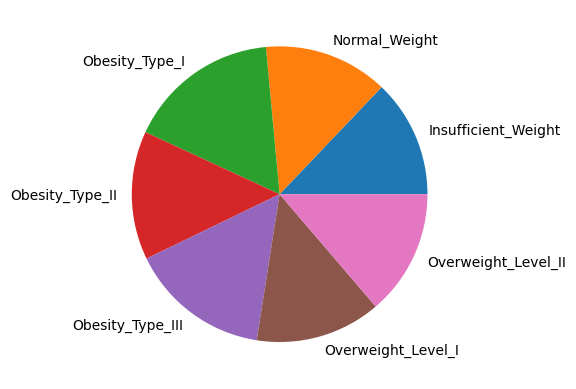

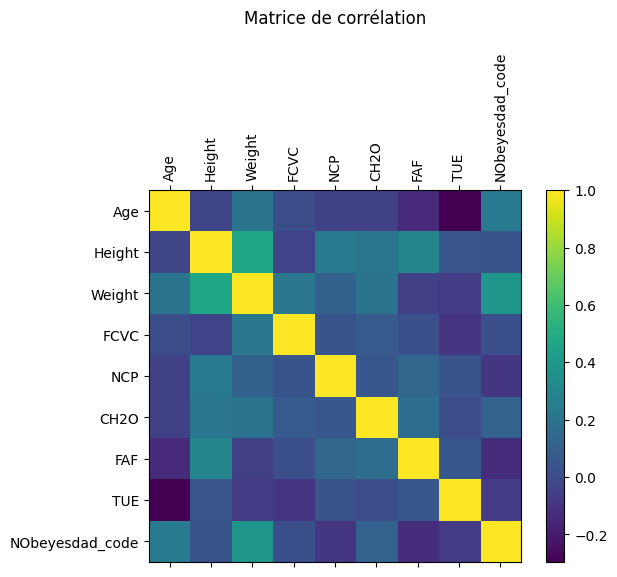

In [51]:
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

data = np.loadtxt("final_data.csv", delimiter = ",", skiprows=1)

Y = data[:,-1]
X = data[:,:-1]

# Vérification du débalancement des données
counter = Counter(Y)
sorted_counter = dict(sorted(counter.items(), key=lambda item:item[0]))

Y1 = []
for key, value in sorted_counter.items():
    print(f"pourcentage {key} : {value*100/len(Y)} %")
    Y1.append(value)
    
plt.figure()
plt.pie(Y1, labels=label["NObeyesdad"].keys())
plt.show()

# Matrice de corrélation
df = pd.read_csv("ObesityDataSet_raw_and_data_sinthetic.csv")

df["NObeyesdad_code"] = df["NObeyesdad"].astype("category").cat.codes

plt.figure()
corr = df.select_dtypes(include="number").corr()

plt.matshow(corr, fignum=1)
plt.title("Matrice de corrélation", pad=20)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.colorbar()
plt.show()



In [52]:
# Séparation des données et train et test
x_train, x_test_val, y_train, y_test_val = train_test_split(X, Y, test_size=0.30, random_state=42)
x_val, x_test, y_val, y_test = train_test_split(x_test_val, y_test_val, test_size=0.5, random_state=42)

# Normalisation
scaler = StandardScaler()
scaler.fit(x_train)
x_train = scaler.transform(x_train)
x_test = scaler.transform(x_test) 
x_val = scaler.transform(x_val)


Les classes ne sont pas débalancées, il n'y a pas besoin de rééchatilloner.

## Régression logistique 

In [53]:
from sklearn.linear_model import LogisticRegression

tab_comp = []

LR = LogisticRegression(random_state=42, max_iter=3000)
LR.fit(x_train, y_train)
acc_LR= LR.score(x_val, y_val)
print("Accuracy pour la régression logistique  : ", acc_LR)

tab_comp.append([acc_LR, "régression logistique"])

Accuracy pour la régression logistique  :  0.8706624605678234


## Réseaux de neurones 

In [54]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(random_state=42, max_iter=3000)
mlp.fit(x_train, y_train)
acc_mlp = mlp.score(x_val, y_val)
print("Accuracy pour les réseaux de neurones : ", acc_mlp)

tab_comp.append([acc_mlp,"Réseaux de neurones"])

Accuracy pour les réseaux de neurones :  0.9148264984227129


## SVM


In [55]:
from sklearn.svm import SVC

svm = SVC(random_state=42)
svm.fit(x_train, y_train)
acc_svm = svm.score(x_val, y_val)
print("Accuracy pour le SVM : ", acc_svm)

tab_comp.append([acc_svm,"SVM"])

Accuracy pour le SVM :  0.861198738170347


## KNN 

In [56]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
knn.fit(x_train, y_train)
acc_knn = knn.score(x_val, y_val)
print("Accuracy pour le KNN : ", acc_knn)

tab_comp.append([acc_knn, "KNN"])

Accuracy pour le KNN :  0.8138801261829653


## Apprentissage probabiliste (GaussianNB)

In [57]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()
gnb.fit(x_train, y_train)
acc_gnb = gnb.score(x_val, y_val)
print("Accuracy pour GaussianNB : ", acc_gnb)

tab_comp.append([acc_gnb, "GaussianNB"])

Accuracy pour GaussianNB :  0.4952681388012618


## Forêt aléatoire

In [58]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(x_train, y_train)
acc_rf = rf.score(x_val, y_val)
print("Accuracy pour forêt aléatoire : ", acc_rf)

tab_comp.append([acc_rf, "Forêt aléatoire"])

Accuracy pour forêt aléatoire :  0.9369085173501577


## Arbre de décision

In [59]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(x_train, y_train)
acc_dt = dt.score(x_val, y_val)
print("Accuracy pour arbre de décision : ", acc_dt)

tab_comp.append([acc_dt, "Arbre de décision"])

Accuracy pour arbre de décision :  0.9526813880126183


## Tableau comparatif

In [60]:
import pandas as pd 
tab_comp.sort(reverse=True)

df_comp = pd.DataFrame(data=tab_comp, columns=["ACCURACY", "MODELE"])

print(df_comp)

   ACCURACY                 MODELE
0  0.952681      Arbre de décision
1  0.936909        Forêt aléatoire
2  0.914826    Réseaux de neurones
3  0.870662  régression logistique
4  0.861199                    SVM
5  0.813880                    KNN
6  0.495268             GaussianNB


On garde les 4 meilleurs modèles : Arbre de décision, Forêt aléatoire, Réseaux de neurones et régression logistique.

# Optimisation des meilleurs modèles

## Régression logistique

In [61]:
from sklearn.model_selection import GridSearchCV


clf_Lasso = GridSearchCV(estimator=LogisticRegression(random_state=42, penalty="l1", solver="saga", max_iter=5000), 
                            param_grid={'C': [0.1, 1, 3, 6, 10, 30, 60, 100]}, scoring="accuracy",  cv=5, n_jobs=-1)
clf_Lasso.fit(x_train, y_train)

clf_Ridge = GridSearchCV(estimator=LogisticRegression(random_state=42, penalty="l2", solver="saga", max_iter=3000), 
                            param_grid={'C': [0.1, 1, 3, 6, 10, 30, 60, 100]}, scoring="accuracy",  cv=5, n_jobs=-1)
clf_Ridge.fit(x_train, y_train)

clf_Elasticnet = GridSearchCV(estimator=LogisticRegression(random_state=42, penalty="elasticnet", solver="saga", max_iter=3000), 
                            param_grid={'C': [0.1, 1, 3, 6, 10, 30, 60, 100], 'l1_ratio': [0.3, 0.5, 0.7]}, scoring="accuracy",  cv=5, n_jobs=-1)
clf_Elasticnet.fit(x_train, y_train)

c:\Users\lamax\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,estimator,LogisticRegre...solver='saga')
,param_grid,"{'C': [0.1, 1, ...], 'l1_ratio': [0.3, 0.5, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'elasticnet'


In [62]:

from sklearn.metrics import f1_score

tab_comp_opti = []

RL_lasso_opti = clf_Lasso.best_estimator_
acc_lasso_opti = RL_lasso_opti.score(x_val, y_val)

RL_ridge_opti = clf_Ridge.best_estimator_
acc_ridge_opti = RL_ridge_opti.score(x_val, y_val)

RL_elasticnet_opti = clf_Elasticnet.best_estimator_
acc_elasticnet_opti = RL_elasticnet_opti.score(x_val, y_val)

print("Accuracy Lasso : ", acc_lasso_opti)
print("Accuracy Ridge : ", acc_ridge_opti)
print("Accuracy Elasticnet : ", acc_elasticnet_opti, "\n")

best_LR = clf_Lasso.best_estimator_
print("meilleur modèle de régression logistique : ", best_LR)

acc_best_lr = best_LR.score(x_val, y_val)
print("Accuracy : ", acc_best_lr, "\n")

tab_comp_opti.append([acc_best_lr, "Lasso"])

Accuracy Lasso :  0.9463722397476341
Accuracy Ridge :  0.943217665615142
Accuracy Elasticnet :  0.9463722397476341 

meilleur modèle de régression logistique :  LogisticRegression(C=6, max_iter=5000, penalty='l1', random_state=42,
                   solver='saga')
Accuracy :  0.9463722397476341 



## Arbre de décision

In [63]:
parametre = {'criterion':['gini', 'entropy', 'log_loss'],
            "max_depth": [None, 3, 5, 10, 15, 30, 50], 
            "min_samples_leaf": [1, 2, 3, 5, 7, 10],
            "min_samples_split": [2, 3, 5, 7, 10]}

clf_dt = GridSearchCV(estimator=DecisionTreeClassifier(random_state=42), param_grid=parametre, scoring="accuracy", cv=5, n_jobs=-1)

clf_dt.fit(x_train, y_train)

,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'criterion': ['gini', 'entropy', ...], 'max_depth': [None, 3, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 3, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'entropy'


In [64]:

best_dt = clf_dt.best_estimator_

print("meilleur modèle d'arbre de décision : ", best_dt)

acc_best_dt = best_dt.score(x_val, y_val)
print("Accuracy : ", acc_best_dt)


tab_comp_opti.append([acc_best_dt, "Arbre de décision"])

meilleur modèle d'arbre de décision :  DecisionTreeClassifier(criterion='entropy', min_samples_leaf=3,
                       min_samples_split=7, random_state=42)
Accuracy :  0.9684542586750788


## Forêt aléatoire 

In [65]:
parametre = {'criterion':['gini', 'entropy', 'log_loss'],
            "max_depth": [None, 3, 5, 10, 15, 30, 50], 
            "min_samples_leaf": [1, 2, 3, 5, 7, 10], 
            "min_samples_split": [2, 3, 5, 7, 10]}

clf_rf = GridSearchCV(estimator=RandomForestClassifier(random_state=42), param_grid=parametre, scoring="accuracy", cv=5, n_jobs=-1)

clf_rf.fit(x_train, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'criterion': ['gini', 'entropy', ...], 'max_depth': [None, 3, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 3, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [66]:
best_rf = clf_rf.best_estimator_
print("Meilleur modèle de forêt aléatoire : ", best_rf)

acc_best_rf = best_rf.score(x_val, y_val)
print("Accuracy : ", acc_best_rf)

tab_comp_opti.append([acc_best_rf, "Forêt aléatoire"])

Meilleur modèle de forêt aléatoire :  RandomForestClassifier(max_depth=15, random_state=42)
Accuracy :  0.9337539432176656


## Réseaux de neurones

In [67]:
parametre = {'activation':['identity', 'logistic', 'tanh', 'relu'], 
            'hidden_layer_sizes':[(100), (24), (24, 24), (24, 24, 24)],
            'alpha':[0.00001, 0.0001, 0.001, 0.01],
            'learning_rate_init':[0.0001, 0.001, 0.01]}

clf_mlp = GridSearchCV(estimator=MLPClassifier(random_state=42), param_grid=parametre, scoring="accuracy",  cv=5, n_jobs=-1)

clf_mlp.fit(x_train, y_train)

,estimator,MLPClassifier(random_state=42)
,param_grid,"{'activation': ['identity', 'logistic', ...], 'alpha': [1e-05, 0.0001, ...], 'hidden_layer_sizes': [100, 24, ...], 'learning_rate_init': [0.0001, 0.001, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,hidden_layer_sizes,"(24, ...)"


In [68]:
best_mlp = clf_mlp.best_estimator_
print("Meilleur modèle pour les réseaux de neurones : ", best_mlp)

acc_best_mlp = best_mlp.score(x_val, y_val)
print("Accuracy : ", acc_best_mlp)

tab_comp_opti.append([acc_best_mlp, "Réseaux de neurones"])

Meilleur modèle pour les réseaux de neurones :  MLPClassifier(activation='identity', alpha=1e-05,
              hidden_layer_sizes=(24, 24, 24), random_state=42)
Accuracy :  0.9684542586750788


In [69]:
tab_comp_opti.sort(reverse=True)

df_comp_opti = pd.DataFrame(data=tab_comp_opti, columns=["ACCURACY", "MODELE"])

print(df_comp_opti)

   ACCURACY               MODELE
0  0.968454  Réseaux de neurones
1  0.968454    Arbre de décision
2  0.946372                Lasso
3  0.933754      Forêt aléatoire


On voit que l'arbre de décision et Lasso on des bons scores. Cela peut être dû au fait qu'il y a une caractéristique qui possède un poids très élevé par rapport au autres comme "weight". On va donc essayer de retirer cette caractéristique et voir comment les modèles réagissent. 

In [70]:
data_no_weight = np.loadtxt("final_data_no_weight.csv", delimiter = ",", skiprows=1)

Y = data[:,-1]
X = data[:,:-1]


# Séparation des données et train et test
x_train_NW, x_test_val, y_train_NW, y_test_val = train_test_split(X, Y, test_size=0.30, random_state=42)
x_val_NW, x_test_NW, y_val_NW, y_test_NW = train_test_split(x_test_val, y_test_val, test_size=0.5, random_state=42)

# Normalisation
scaler = StandardScaler()
scaler.fit(x_train_NW)
x_train_NW = scaler.transform(x_train_NW)
x_test_NW = scaler.transform(x_test_NW) 
x_val_NW = scaler.transform(x_val_NW)

In [71]:
clf_Lasso = GridSearchCV(estimator=LogisticRegression(random_state=42, penalty="l1", solver="saga", max_iter=5000), 
                            param_grid={'C': [0.1, 1, 3, 6, 10, 30, 60, 100]}, scoring="accuracy",  cv=5, n_jobs=-1)
clf_Lasso.fit(x_train_NW, y_train_NW)


parametre_dt = {'criterion':['gini', 'entropy', 'log_loss'],
            "max_depth": [None, 3, 5, 10, 15, 30, 50], 
            "min_samples_leaf": [1, 2, 3, 5, 7, 10],
            "min_samples_split": [2, 3, 5, 7, 10]}
clf_dt = GridSearchCV(estimator=DecisionTreeClassifier(random_state=42), param_grid=parametre_dt, scoring="accuracy",  cv=5, n_jobs=-1)
clf_dt.fit(x_train_NW, y_train_NW)


parametre_rf = {'criterion':['gini', 'entropy', 'log_loss'],
            "max_depth": [None, 3, 5, 10, 15, 30, 50], 
            "min_samples_leaf": [1, 2, 3, 5, 7, 10], 
            "min_samples_split": [2, 3, 5, 7, 10]}
clf_rf = GridSearchCV(estimator=RandomForestClassifier(random_state=42), param_grid=parametre_rf, scoring="accuracy",  cv=5, n_jobs=-1)
clf_rf.fit(x_train_NW, y_train_NW)


parametre_mlp = {'activation':['identity', 'logistic', 'tanh', 'relu'], 
            'hidden_layer_sizes':[(100), (23), (23, 23), (23, 23, 23)],
            'alpha':[0.00001, 0.0001, 0.001, 0.01],
            'learning_rate_init':[0.0001, 0.001, 0.01]}
clf_mlp = GridSearchCV(estimator=MLPClassifier(random_state=42), param_grid=parametre_mlp, scoring="accuracy",  cv=5, n_jobs=-1)
clf_mlp.fit(x_train_NW, y_train_NW)

,estimator,MLPClassifier(random_state=42)
,param_grid,"{'activation': ['identity', 'logistic', ...], 'alpha': [1e-05, 0.0001, ...], 'hidden_layer_sizes': [100, 23, ...], 'learning_rate_init': [0.0001, 0.001, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,hidden_layer_sizes,"(23, ...)"


In [72]:

best_LR = clf_Lasso.best_estimator_
print("meilleur modèle de régression logistique : ", best_LR)
acc_best_lr = best_LR.score(x_val_NW, y_val_NW)
print("Accuracy : ", acc_best_lr, "\n")



best_dt = clf_dt.best_estimator_
print("meilleur modèle d'arbre de décision : ", best_dt)
acc_best_dt = best_dt.score(x_val_NW, y_val_NW)
print("Accuracy : ", acc_best_dt, "\n")



best_rf = clf_rf.best_estimator_
print("Meilleur modèle de forêt aléatoire : ", best_rf)
acc_best_rf = best_rf.score(x_val_NW, y_val_NW)
print("Accuracy : ", acc_best_rf, "\n")



best_mlp = clf_mlp.best_estimator_
print("Meilleur modèle pour les réseaux de neurones : ", best_mlp)
acc_best_mlp = best_mlp.score(x_val_NW, y_val_NW)
print("Accuracy : ", acc_best_mlp)



meilleur modèle de régression logistique :  LogisticRegression(C=6, max_iter=5000, penalty='l1', random_state=42,
                   solver='saga')
Accuracy :  0.9463722397476341 

meilleur modèle d'arbre de décision :  DecisionTreeClassifier(criterion='entropy', min_samples_leaf=3,
                       min_samples_split=7, random_state=42)
Accuracy :  0.9684542586750788 

Meilleur modèle de forêt aléatoire :  RandomForestClassifier(max_depth=15, random_state=42)
Accuracy :  0.9337539432176656 

Meilleur modèle pour les réseaux de neurones :  MLPClassifier(activation='identity', alpha=0.01, hidden_layer_sizes=(23, 23),
              learning_rate_init=0.01, random_state=42)
Accuracy :  0.9621451104100947


On voit que retirer une caractéristique ne change rien.

# Matrices de confusions

## Lasso

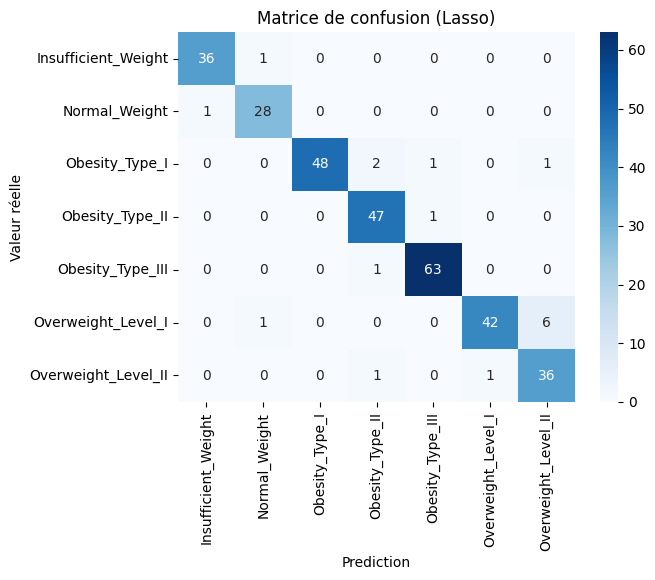

In [73]:

from sklearn.metrics import confusion_matrix
import seaborn as sns

cm_LR = confusion_matrix(y_val, best_LR.predict(x_val))
plt.figure()
sns.heatmap(cm_LR, annot=True, cmap='Blues', xticklabels=label["NObeyesdad"].keys(), yticklabels=label["NObeyesdad"].keys())
plt.title("Matrice de confusion (Lasso)")
plt.xlabel("Prediction")
plt.ylabel("Valeur réelle")
plt.show()



## Arbre de décision

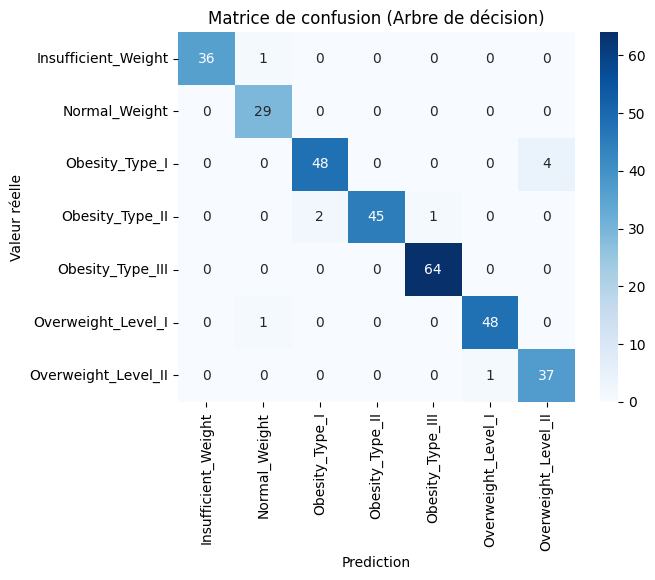

In [74]:
cm_DT = confusion_matrix(y_val, best_dt.predict(x_val))
plt.figure()
sns.heatmap(cm_DT, annot=True, cmap='Blues', xticklabels=label["NObeyesdad"].keys(), yticklabels=label["NObeyesdad"].keys())
plt.title("Matrice de confusion (Arbre de décision)")
plt.xlabel("Prediction")
plt.ylabel("Valeur réelle")
plt.show()

## Réseau de neurones

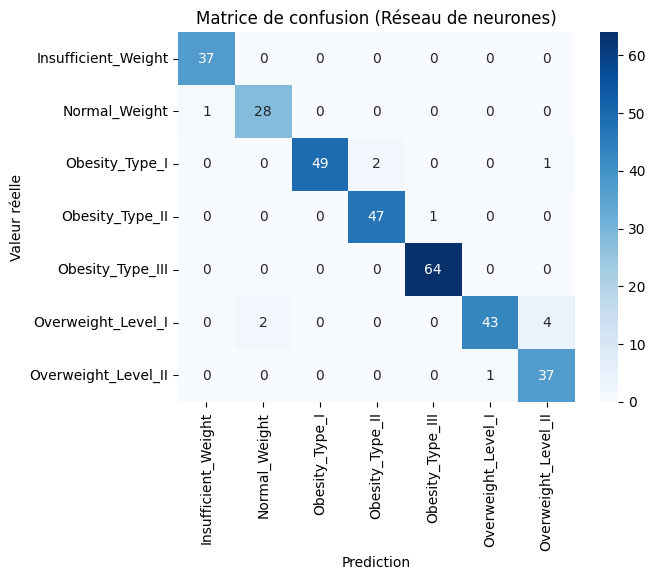

In [75]:
cm_mlp = confusion_matrix(y_val, best_mlp.predict(x_val))
plt.figure()
sns.heatmap(cm_mlp, annot=True, cmap='Blues', xticklabels=label["NObeyesdad"].keys(), yticklabels=label["NObeyesdad"].keys())
plt.title("Matrice de confusion (Réseau de neurones)")
plt.xlabel("Prediction")
plt.ylabel("Valeur réelle")
plt.show()

## Forêt aléatoire

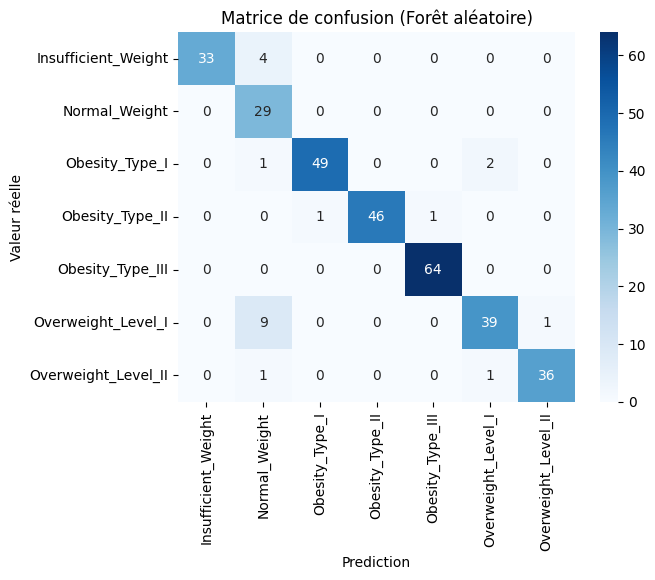

In [76]:
cm_rf = confusion_matrix(y_val, best_rf.predict(x_val))
plt.figure()
sns.heatmap(cm_rf, annot=True, cmap='Blues', xticklabels=label["NObeyesdad"].keys(), yticklabels=label["NObeyesdad"].keys())
plt.title("Matrice de confusion (Forêt aléatoire)")
plt.xlabel("Prediction")
plt.ylabel("Valeur réelle")
plt.show()

## Aprentissage d'ensemble

In [77]:
from sklearn.ensemble import VotingClassifier

estimators = []

estimators.append(('lasso', best_LR))
estimators.append(('mlp', best_mlp))
estimators.append(('arbre de décision', best_dt))
estimators.append(('Forêt aléatoire', best_rf))

vc = VotingClassifier(estimators, voting="soft", n_jobs=-1)
vc.fit(x_train, y_train)


,estimators,"[('lasso', ...), ('mlp', ...), ...]"
,voting,'soft'
,weights,None
,n_jobs,-1
,flatten_transform,True
,verbose,False
,penalty,'l1'
,dual,False
,tol,0.0001
,C,6
,fit_intercept,True


In [78]:
acc_vc = vc.score(x_val, y_val)

print("Accuracy pour l'apprentissage d'ensemble : ", acc_vc)


Accuracy pour l'apprentissage d'ensemble :  0.9747634069400631


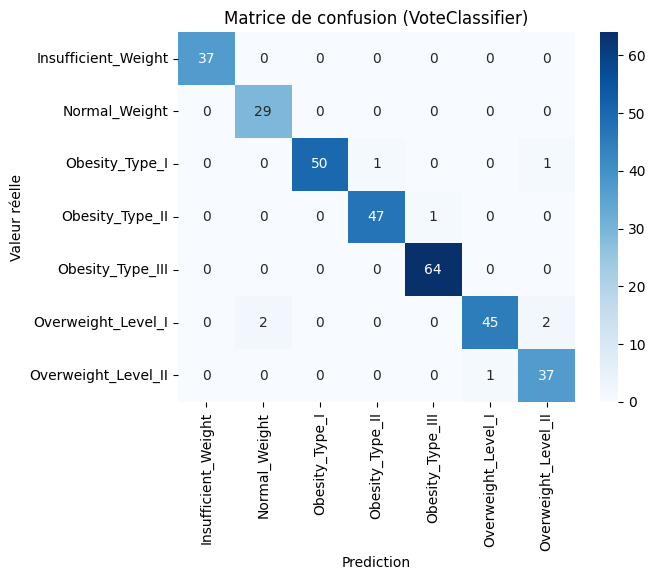

In [79]:
cm_vc = confusion_matrix(y_val, vc.predict(x_val))
plt.figure()
sns.heatmap(cm_vc, annot=True, cmap='Blues', xticklabels=label["NObeyesdad"].keys(), yticklabels=label["NObeyesdad"].keys())
plt.title("Matrice de confusion (VoteClassifier)")
plt.xlabel("Prediction")
plt.ylabel("Valeur réelle")
plt.show()

On ne garde que les 3 modèles les plus performant et le VoteClassifier pour la sélection finale.

## Prédiction sur l'ensemble de test

In [80]:
from sklearn.metrics import precision_recall_fscore_support

prfs_mlp = precision_recall_fscore_support(y_test, best_mlp.predict(x_test), average="macro")
prfs_lasso = precision_recall_fscore_support(y_test, best_LR.predict(x_test), average="macro")
prfs_dt = precision_recall_fscore_support(y_test, best_dt.predict(x_test), average="macro")
prfs_vc = precision_recall_fscore_support(y_test, vc.predict(x_test), average="macro")

dt = pd.DataFrame(np.array([[prfs_dt[0], prfs_mlp[0], prfs_lasso[0], prfs_vc[0]],
                            [prfs_dt[1], prfs_mlp[1], prfs_lasso[1], prfs_vc[1]],
                            [prfs_dt[2], prfs_mlp[2], prfs_lasso[2], prfs_vc[2]],
                            [best_dt.score(x_test, y_test), best_mlp.score(x_test, y_test), best_LR.score(x_test, y_test), vc.score(x_test, y_test)]]),
                columns=["Arbre de décision", "Réseaux de neurones", "Lasso", "VoteClassifier"], index=["Precision", "Recall", "F1score", "Accuracy"])

dt

,Arbre de décision,Réseaux de neurones,Lasso,VoteClassifier
Precision,0.941095,0.966763,0.949929,0.981529
Recall,0.938856,0.965057,0.948644,0.981470
F1score,0.939481,0.965021,0.948536,0.981023
Accuracy,0.940063,0.965300,0.949527,0.981073
